In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

df = pd.read_csv('simple_cyber_messages.csv')
display(df.head())
print('Dataset shape:', df.shape)

,message_id,message,correct_category
0,1,The department meeting is scheduled for 2 PM i...,Safe
1,2,Your account will be suspended. Click here and...,Phishing
2,3,The attached executable file contains a trojan...,Malware
3,4,Your files have been encrypted. Pay bitcoin to...,Ransomware
4,5,Library books must be returned before Friday.,Safe


Dataset shape: (28, 3)


## Q1. Manual Threat Identification

The first ten messages are reviewed using the indicators suggested in the lab manual. The important-word list below follows the manual's supplied examples; the final category is taken from the dataset's `correct_category` column.

In [ ]:
manual_table = df.head(10)[['message_id', 'message', 'correct_category']].copy()
manual_table['important_words'] = [
    'meeting, scheduled',
    'suspended, click here, verify, password',
    'urgently',
    'executable, trojan, infect',
    'encrypted, bitcoin, restore files',
    'library, returned',
    'prize, login, claim',
    'spyware, attachment',
    'locked files, ransom, payment',
    'official portal',
]
display(manual_table)

,message_id,message,correct_category,important_words
0,1,The department meeting is scheduled for 2 PM i...,Safe,"meeting, scheduled"
1,2,Your account will be suspended. Click here and...,Phishing,"suspended, click here, verify, password"
2,3,The attached executable file contains a trojan...,Malware,urgently
3,4,Your files have been encrypted. Pay bitcoin to...,Ransomware,"executable, trojan, infect"
4,5,Library books must be returned before Friday.,Safe,"encrypted, bitcoin, restore files"
5,6,Congratulations! You won a prize. Login now to...,Phishing,"library, returned"
6,7,Antivirus detected spyware in the downloaded a...,Malware,"prize, login, claim"
7,8,Locked files will be released only after ranso...,Ransomware,"spyware, attachment"
8,9,Your monthly attendance report is available on...,Safe,"locked files, ransom, payment"
9,10,Urgent bank alert: verify account and share OT...,Phishing,official portal


**Observation:** Safe messages should still be checked in context because an apparently normal message can contain misleading wording or could be part of a larger suspicious communication pattern.

## Q2. Keyword Lists and Rule-Based Classifier

In [ ]:
RULE_KEYWORDS = {
    'Phishing': [
        'click here', 'verify', 'password', 'urgent',
        'otp', 'prize', 'bank', 'login', 'blocked'
    ],
    'Malware': [
        'malware', 'virus', 'infected', 'attachment',
        'trojan', 'spyware', 'executable'
    ],
    'Ransomware': [
        'encrypted', 'ransom', 'bitcoin', 'restore files',
        'locked files', 'unlock', 'payment demand'
    ]
}

def classify_message(text):
    text = str(text).lower()
    scores = {
        category: sum(word in text for word in words)
        for category, words in RULE_KEYWORDS.items()
    }
    predicted = max(scores, key=scores.get)
    if scores[predicted] == 0:
        return 'Safe', '', 0
    matched = [
        word for word in RULE_KEYWORDS[predicted]
        if word in text
    ]
    return predicted, ', '.join(matched), scores[predicted]

print(classify_message('Urgent: click here to verify your password'))

('Phishing', 'click here, verify, password, urgent', 4)


### Four test messages

The first test is the manual's example. The remaining tests include Phishing, Malware/Ransomware, and Safe cases.

In [ ]:
test_messages = [
    'Urgent: click here to verify your password',
    'Your bank account is blocked. Verify your OTP now.',
    'The executable contains a trojan and may infect your computer.',
    'The meeting is scheduled for tomorrow at 10 AM.'
]

for msg in test_messages:
    print(msg)
    print('Result:', classify_message(msg))
    print()

print('Limitation: keyword rules may miss synonyms, context, obfuscated wording, or new attack language.')

Urgent: click here to verify your password
Result: ('Phishing', 'click here, verify, password, urgent', 4)

Your bank account is blocked. Verify your OTP now.
Result: ('Phishing', 'verify, otp, bank, blocked', 4)

The executable contains a trojan and may infect your computer.
Result: ('Malware', 'trojan, executable', 2)

The meeting is scheduled for tomorrow at 10 AM.
Result: ('Safe', '', 0)

Limitation: keyword rules may miss synonyms, context, obfuscated wording, or new attack language.


## Q3. Complete Dataset Classification and Accuracy

In [ ]:
results = df['message'].apply(classify_message)
df[['predicted_category', 'matched_keywords', 'keyword_score']] = pd.DataFrame(
    results.tolist(), index=df.index
)

df['correct'] = df['correct_category'] == df['predicted_category']
accuracy = accuracy_score(df['correct_category'], df['predicted_category'])

display(df[[
    'message_id', 'correct_category', 'predicted_category',
    'matched_keywords', 'correct'
]])

correct_predictions = int(df['correct'].sum())
incorrect_predictions = len(df) - correct_predictions

print('Correct predictions:', correct_predictions)
print('Incorrect predictions:', incorrect_predictions)
print(f'Accuracy: {accuracy * 100:.2f}%')

,message_id,correct_category,predicted_category,matched_keywords,correct
0,1,Safe,Safe,,True
1,2,Phishing,Phishing,"click here, verify, password, urgent",True
2,3,Malware,Malware,"trojan, executable",True
3,4,Ransomware,Ransomware,"encrypted, bitcoin, restore files",True
4,5,Safe,Safe,,True
5,6,Phishing,Phishing,"prize, login",True
6,7,Malware,Malware,"virus, attachment, spyware",True
7,8,Ransomware,Ransomware,"ransom, locked files",True
8,9,Safe,Safe,,True
9,10,Phishing,Phishing,"verify, urgent, otp, bank",True


Correct predictions: 27
Incorrect predictions: 1
Accuracy: 96.43%


### Observation

Accuracy is the proportion of correct predictions among all predictions. A high score on this small classroom dataset should not be treated as proof of real-world effectiveness. The lab manual notes that its supplied classroom result is approximately **28 correct out of 28 (100%)**; the actual result above is calculated from the CSV loaded into this notebook.

## Q4. Risk Level, Recommended Action and Bar Chart

,message_id,predicted_category,keyword_score,risk_level,recommended_action
0,1,Safe,0,Low,Continue normal caution.
1,2,Phishing,4,High,Do not click/open; isolate if required and rep...
2,3,Malware,2,High,Do not click/open; isolate if required and rep...
3,4,Ransomware,3,High,Do not click/open; isolate if required and rep...
4,5,Safe,0,Low,Continue normal caution.
5,6,Phishing,2,High,Do not click/open; isolate if required and rep...
6,7,Malware,3,High,Do not click/open; isolate if required and rep...
7,8,Ransomware,2,High,Do not click/open; isolate if required and rep...
8,9,Safe,0,Low,Continue normal caution.
9,10,Phishing,4,High,Do not click/open; isolate if required and rep...


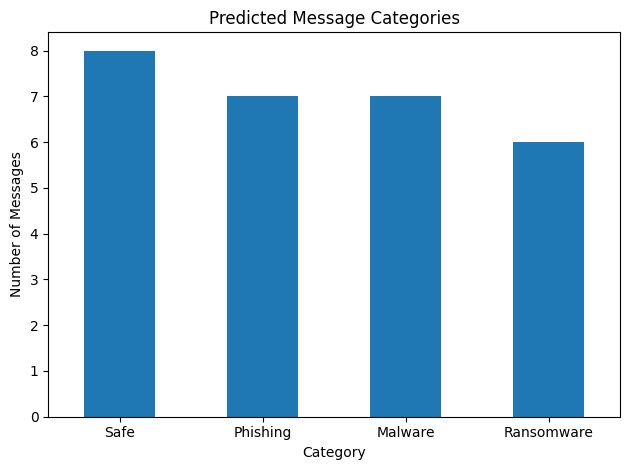

In [ ]:
def add_risk_and_action(row):
    if row['predicted_category'] == 'Safe':
        return 'Low', 'Continue normal caution.'
    if row['predicted_category'] == 'Ransomware' or row['keyword_score'] >= 2:
        return 'High', 'Do not click/open; isolate if required and report.'
    return 'Medium', 'Do not interact; verify the sender and report.'

risk_output = df.apply(add_risk_and_action, axis=1)
df[['risk_level', 'recommended_action']] = pd.DataFrame(
    risk_output.tolist(), index=df.index
)

display(df[['message_id', 'predicted_category', 'keyword_score', 'risk_level', 'recommended_action']])

category_order = ['Safe', 'Phishing', 'Malware', 'Ransomware']
category_counts = df['predicted_category'].value_counts().reindex(category_order, fill_value=0)

category_counts.plot(kind='bar')
plt.title('Predicted Message Categories')
plt.xlabel('Category')
plt.ylabel('Number of Messages')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Live/new-message demonstration
new_message = 'Urgent: your bank account is blocked. Verify your OTP and password.'
prediction = classify_message(new_message)
print('New message:', new_message)
print('Classification:', prediction)

category, matched, score = prediction
if category == 'Safe':
    print('Risk: Low')
    print('Action: Continue normal caution.')
elif category == 'Ransomware' or score >= 2:
    print('Risk: High')
    print('Action: Do not click/open; isolate if required and report.')
else:
    print('Risk: Medium')
    print('Action: Do not interact; verify the sender and report.')

New message: Urgent: your bank account is blocked. Verify your OTP and password.
Classification: ('Phishing', 'verify, password, urgent, otp, bank, blocked', 6)
Risk: High
Action: Do not click/open; isolate if required and report.


**Why High-risk results require verification:** multiple warning indicators or ransomware classification can indicate serious risk. The rule-based result is a screening aid, not a final decision, so serious or unclear cases should be checked by a human analyst.

## Q5. Responsible Use, Reflection and File Saving

In [ ]:
responsible_use = [
    'Privacy: remove personal identifiers before analysis.',
    'Bias: keyword lists may not cover every writing style.',
    'False alarms: safe messages may contain warning words.',
    'Accountability: humans remain responsible for action.',
    'Human review: high-risk or unclear cases must be checked.'
]

for point in responsible_use:
    print('-', point)

df.to_csv('Lab1_Final_Result.csv', index=False)
print('Saved: Lab1_Final_Result.csv')

- Privacy: remove personal identifiers before analysis.
- Bias: keyword lists may not cover every writing style.
- False alarms: safe messages may contain warning words.
- Accountability: humans remain responsible for action.
- Human review: high-risk or unclear cases must be checked.
Saved: Lab1_Final_Result.csv


## Conclusion

Rule-based AI can provide a simple, transparent and explainable first layer for recognizing common cyber-threat indicators. It is easy to implement because the decision rules and matched keywords can be inspected by a human. However, it is limited by the keywords chosen by the designer and may miss synonyms, unfamiliar wording, context, or new attack techniques. False alarms and missed attacks are possible. Therefore, the system should support—not replace—human cyber-security judgment, especially for high-risk or unclear messages.